In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\BluRay\OneDrive\Desktop\BankingCustomerAnalysis\credit_card_customers.csv")

## Handle Missing Values

In [3]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [4]:
df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median(), inplace=True)

df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median(), inplace=True)

C:\Users\BluRay\AppData\Local\Temp\ipykernel_31684\740186057.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median(), inplace=True)
C:\Users\BluRay\AppData\Local\Temp\ipykernel_31684\740186057.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

In [5]:
df.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

## Duplicate Records Check

In [6]:
df.duplicated().sum()

np.int64(0)

## Invalid Value Check

In [7]:
numeric_cols = df.select_dtypes(include=["float64","int64"]).columns

(df[numeric_cols] < 0).sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

## Feature Distribution Analysis

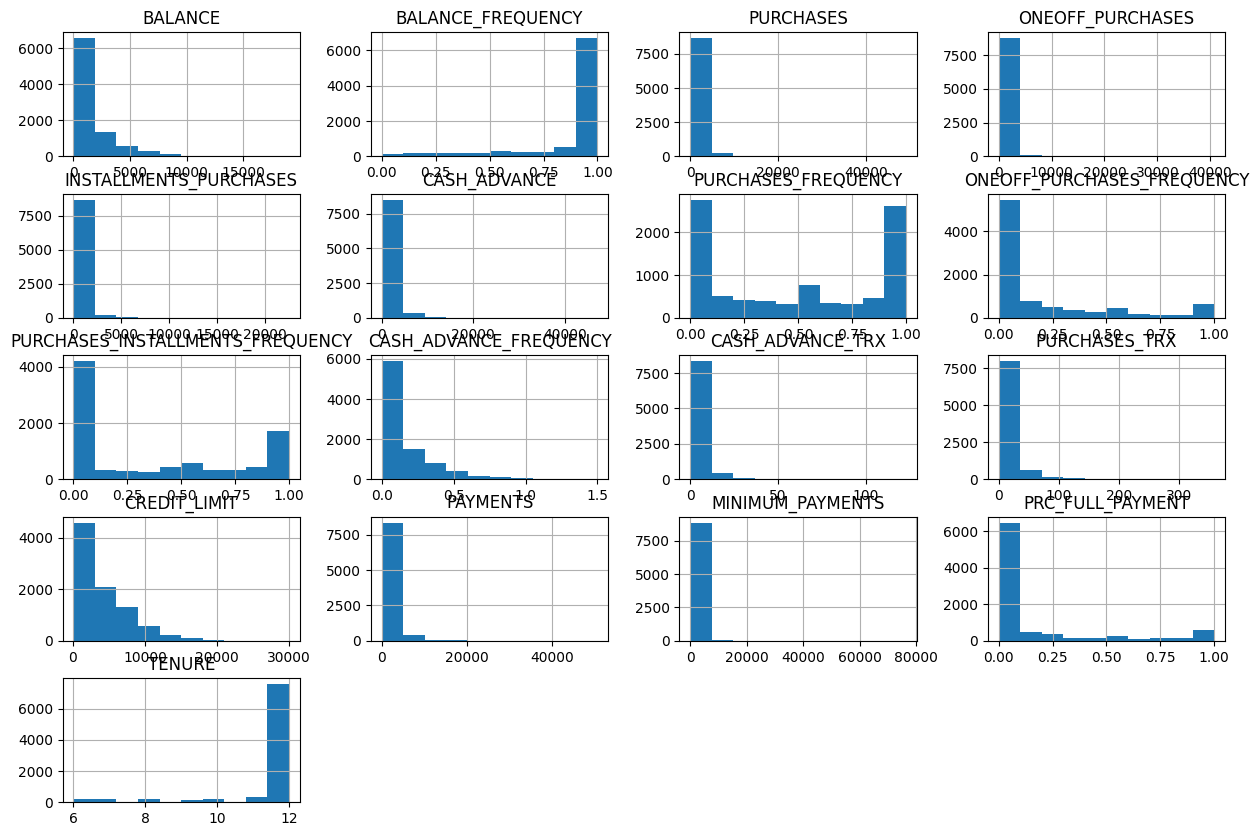

In [8]:
df.hist(figsize=(15,10))
plt.show()

## Outlier Visualization

Text(0.5, 1.0, 'Customer Balance Distribution')

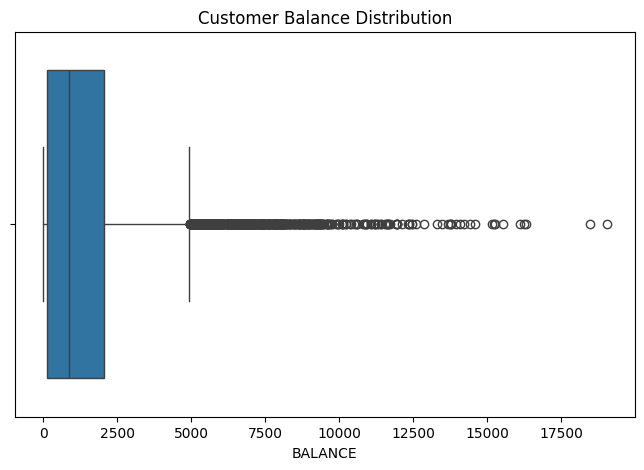

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["BALANCE"])

plt.title("Customer Balance Distribution")

## Correlation Analysis

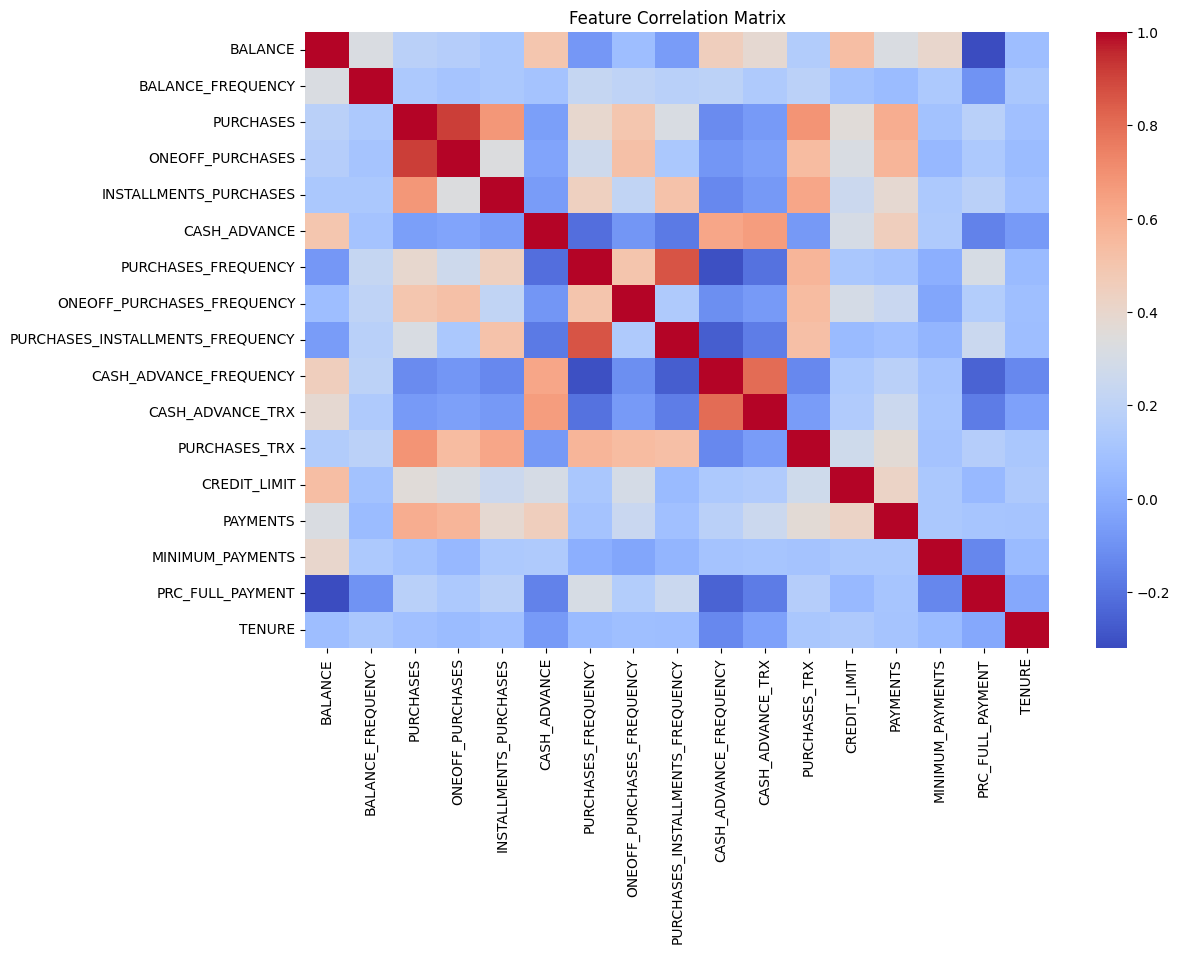

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()

## Key Financial Relationships

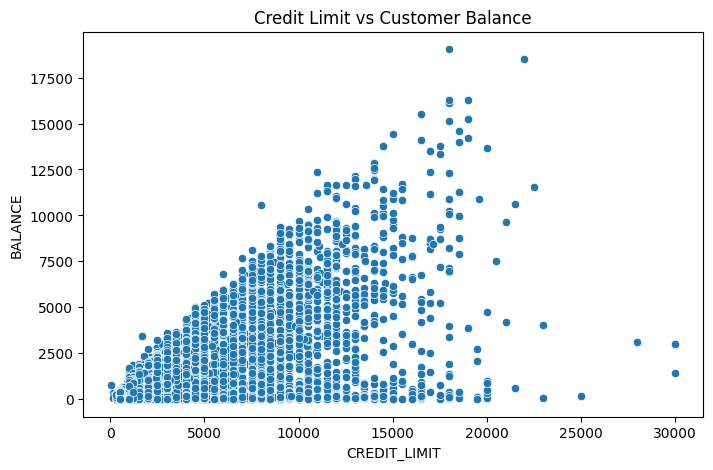

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="CREDIT_LIMIT", y="BALANCE", data=df)

plt.title("Credit Limit vs Customer Balance")

plt.show()

## Customer Purchase Behavior

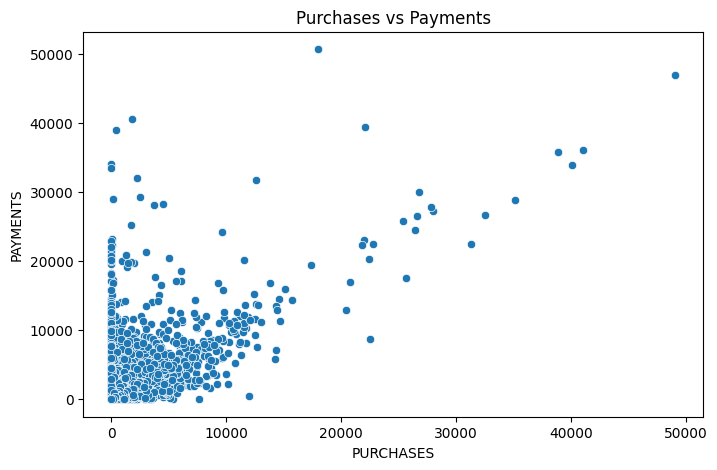

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="PURCHASES", y="PAYMENTS", data=df)

plt.title("Purchases vs Payments")

plt.show()

## Key Observations:

• Financial transaction variables show strong right skew.
• A small portion of customers generate very high transaction values.
• Credit limit strongly influences customer balance.
• Some customers rely heavily on cash advances.
• Payment behavior varies significantly across customers.

In [14]:
df.to_csv("C:\\Users\\BluRay\\OneDrive\\Desktop\\BankingCustomerAnalysis\\credit_card_customers_cleaned.csv", index=False)